# 📊 Notebook 04: Síntese e Visualizações Finais
## Análise de Desigualdades de Gênero na Educação Básica Brasileira

**Autora:** Sara - Mestra em Educação

### 📋 Objetivos deste notebook:
1. Integrar todas as análises realizadas
2. Criar visualizações síntese de alto impacto
3. Elaborar recomendações de políticas públicas
4. Gerar relatório final da análise

---

In [1]:
# Importações
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# Adicionar diretório de scripts ao path
import sys
sys.path.append('../scripts')

# Importar configurações
from config import CORES, GRAPHICS_PATH, PROCESSED_DATA_PATH, OUTPUTS_PATH

# Configurações de visualização
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 11

print("✅ Bibliotecas importadas!")

✅ Configurações carregadas!
📁 Dados brutos: /home/sara/Censo25/data/
📁 Dados processados: /home/sara/Censo25/data/processed/
📁 Gráficos: /home/sara/Censo25/outputs/figures/
✅ Bibliotecas importadas!


## 1️⃣ Carregar Todos os Dados Processados

In [ ]:
# Carregar dados
df = pd.read_csv(PROCESSED_DATA_PATH + 'escolas_analise.csv', encoding='utf-8')

print(f"✅ Dados carregados: {len(df):,} escolas")
print(f"   • {len(df):,} escolas ativas")
print(f"   • Todas com dados de matrículas e gestão")

# FUNÇÃO REUTILIZÁVEL: Calcular todas as métricas principais
def calcular_metricas_principais(df):
    """
    Calcula todas as métricas principais de gênero de uma vez.
    Evita cálculos duplicados e melhora a organização do código.
    
    Retorna:
        dict: Dicionário com todas as métricas calculadas
    """
    metrics = {}
    
    # Matrículas
    metrics['total_fem'] = df['QT_MAT_BAS_FEM'].sum()
    metrics['total_masc'] = df['QT_MAT_BAS_MASC'].sum()
    metrics['total_geral'] = metrics['total_fem'] + metrics['total_masc']
    metrics['pct_fem'] = (metrics['total_fem'] / metrics['total_geral']) * 100
    metrics['pct_masc'] = (metrics['total_masc'] / metrics['total_geral']) * 100
    
    # Gestores
    metrics['total_gestoras'] = df['QT_GEST_BAS_FEM'].sum()
    metrics['total_gestores'] = df['QT_GEST_BAS_MASC'].sum()
    metrics['total_gest_geral'] = metrics['total_gestoras'] + metrics['total_gestores']
    metrics['pct_gestoras'] = (metrics['total_gestoras'] / metrics['total_gest_geral']) * 100
    metrics['pct_gestores'] = (metrics['total_gestores'] / metrics['total_gest_geral']) * 100
    
    # Diferença chave
    metrics['diferenca_gestao_alunas'] = metrics['pct_gestoras'] - metrics['pct_fem']
    
    return metrics

# Calcular métricas uma única vez
print("\n📊 Calculando métricas principais...")
m = calcular_metricas_principais(df)
print(f"✅ Métricas calculadas!")

## 2️⃣ Dashboard Integrado: Panorama Geral de Gênero na Educação

In [ ]:
# Criar dashboard integrado
fig = plt.figure(figsize=(20, 14))
gs = GridSpec(3, 3, figure=fig, hspace=0.35, wspace=0.35)

# Título geral
fig.suptitle('Desigualdades de Gênero na Educação Básica Brasileira\nCenso Escolar 2025',
             fontsize=20, fontweight='bold', y=0.98)

# 1. Panorama nacional - Matrículas (topo esquerda)
ax1 = fig.add_subplot(gs[0, 0])
total_fem = df['QT_MAT_BAS_FEM'].sum()
total_masc = df['QT_MAT_BAS_MASC'].sum()
total_geral = total_fem + total_masc
pct_fem = (total_fem / total_geral) * 100
pct_masc = (total_masc / total_geral) * 100

ax1.bar(['Meninas', 'Meninos'], [pct_fem, pct_masc],
        color=[CORES['feminino'], CORES['masculino']], alpha=0.8)
ax1.axhline(y=50, color=CORES['neutro'], linestyle='--', linewidth=2, alpha=0.5)
ax1.set_title('Matrículas Educação Básica', fontweight='bold', fontsize=13)
ax1.set_ylabel('Porcentagem (%)', fontsize=11)
ax1.set_ylim(0, 100)
ax1.grid(axis='y', alpha=0.3)

for i, (val, label) in enumerate(zip([pct_fem, pct_masc], ['Meninas', 'Meninos'])):
    ax1.text(i, val + 2, f'{val:.1f}%\n{val/100*total_geral:,.0f}',
             ha='center', va='bottom', fontweight='bold', fontsize=10)

# 2. Panorama nacional - Gestores (topo centro)
ax2 = fig.add_subplot(gs[0, 1])
total_gestoras = df['QT_GEST_BAS_FEM'].sum()
total_gestores = df['QT_GEST_BAS_MASC'].sum()
total_gest_geral = total_gestoras + total_gestores
pct_gestoras = (total_gestoras / total_gest_geral) * 100
pct_gestores = (total_gestores / total_gest_geral) * 100

sizes = [pct_gestoras, pct_gestores]
labels = [f'Gestoras\n{pct_gestoras:.1f}%', f'Gestores\n{pct_gestores:.1f}%']
colors = [CORES['feminino'], CORES['masculino']]

ax2.pie(sizes, labels=labels, colors=colors, autopct='', startangle=90,
       textprops={'fontweight': 'bold', 'fontsize': 11})
ax2.set_title('Gestores Escolares', fontweight='bold', fontsize=13)

# 3. Por rede de ensino - Matrículas (topo direita)
ax3 = fig.add_subplot(gs[0, 2])
df_rede_mat = df.groupby('TP_DEPENDENCIA')[['QT_MAT_BAS_FEM', 'QT_MAT_BAS_MASC']].sum()
df_rede_mat['% Meninas'] = (df_rede_mat['QT_MAT_BAS_FEM'] / 
                        (df_rede_mat['QT_MAT_BAS_FEM'] + df_rede_mat['QT_MAT_BAS_MASC']) * 100)

redes = df_rede_mat.index.tolist()
x = np.arange(len(redes))
ax3.bar(x, df_rede_mat['% Meninas'], color=CORES['feminino'], alpha=0.8)
ax3.axhline(y=50, color=CORES['neutro'], linestyle='--', linewidth=2, alpha=0.5)
ax3.set_xticks(x)
ax3.set_xticklabels(redes, rotation=45, ha='right', fontsize=9)
ax3.set_title('% Meninas por Rede', fontweight='bold', fontsize=13)
ax3.set_ylabel('Porcentagem (%)', fontsize=11)
ax3.grid(axis='y', alpha=0.3)

# 4. Gestoras por rede (meio esquerda)
ax4 = fig.add_subplot(gs[1, 0])
df_rede_gest = df.groupby('TP_DEPENDENCIA')[['QT_GEST_BAS_FEM', 'QT_GEST_BAS_MASC']].sum()
df_rede_gest['% Gestoras'] = (df_rede_gest['QT_GEST_BAS_FEM'] / 
                        (df_rede_gest['QT_GEST_BAS_FEM'] + df_rede_gest['QT_GEST_BAS_MASC']) * 100)

redes = df_rede_gest.index.tolist()
x = np.arange(len(redes))
width = 0.35

bars1 = ax4.bar(x - width/2, df_rede_gest['% Gestoras'], width, label='Gestoras',
               color=CORES['destaque'], alpha=0.8)
bars2 = ax4.bar(x + width/2, 100 - df_rede_gest['% Gestoras'], width, label='Gestores',
               color=CORES['masculino'], alpha=0.8)
ax4.axhline(y=50, color=CORES['neutro'], linestyle='--', linewidth=2, alpha=0.5)
ax4.set_xlabel('Rede de Ensino', fontsize=11, fontweight='bold')
ax4.set_ylabel('Porcentagem (%)', fontsize=11)
ax4.set_title('% Gestoras por Rede', fontweight='bold', fontsize=13)
ax4.set_xticks(x)
ax4.set_xticklabels(redes)
ax4.legend(loc='lower right', fontsize=9)
ax4.grid(axis='y', alpha=0.3)
ax4.set_ylim(0, 100)

# 5. Por região - Gestoras (meio centro)
ax5 = fig.add_subplot(gs[1, 1])
df_regiao_gest = df.groupby('NO_REGIAO')[['QT_GEST_BAS_FEM', 'QT_GEST_BAS_MASC']].sum()
df_regiao_gest['% Gestoras'] = (df_regiao_gest['QT_GEST_BAS_FEM'] / 
                        (df_regiao_gest['QT_GEST_BAS_FEM'] + df_regiao_gest['QT_GEST_BAS_MASC']) * 100)
df_regiao_gest = df_regiao_gest.sort_values('% Gestoras', ascending=False)

regioes = df_regiao_gest.index.tolist()
y_pos = np.arange(len(regioes))

bars = ax5.barh(y_pos, df_regiao_gest['% Gestoras'],
           color=[CORES['destaque'] if x >= 80 else CORES['neutro'] 
                  for x in df_regiao_gest['% Gestoras']], alpha=0.8)
ax5.axvline(x=50, color=CORES['masculino'], linestyle='--', linewidth=2, alpha=0.5)
ax5.set_xlabel('% Gestoras', fontsize=11, fontweight='bold')
ax5.set_title('Gestoras por Região', fontweight='bold', fontsize=13)
ax5.set_yticks(y_pos)
ax5.set_yticklabels(regioes)
ax5.set_xlim(60, 90)  # NOTA: Escala ampliada para destacar variações regionais
ax5.text(0.5, -0.15, 
         "Nota: Escala ampliada (60-90%) para destacar variações regionais",
         transform=ax5.transAxes, ha='center', fontsize=8, style='italic', color='gray')
ax5.grid(axis='x', alpha=0.3)

# 6. Comparação Alunas vs Gestoras (meio direito)
ax6 = fig.add_subplot(gs[1, 2])

pct_meninas = (total_fem / total_geral) * 100
pct_gestoras = (total_gestoras / total_gest_geral) * 100

categorias = ['Meninas\n(sala)', 'Gestoras\n(gestão)']
valores = [pct_meninas, pct_gestoras]
cores_comp = [CORES['feminino'], CORES['destaque']]

bars = ax6.bar(categorias, valores, color=cores_comp, alpha=0.8)
ax6.axhline(y=50, color=CORES['neutro'], linestyle='--', linewidth=2, alpha=0.5)
ax6.set_ylabel('Porcentagem (%)', fontsize=11, fontweight='bold')
ax6.set_title('Alunas vs Gestoras', fontweight='bold', fontsize=13)
ax6.set_ylim(0, 100)
ax6.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, valores):
    ax6.text(bar.get_x() + bar.get_width()/2., val + 2,
            f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

# 7. Por região - Matrículas (inferior)
ax7 = fig.add_subplot(gs[2, :])
df_regiao_mat = df.groupby('NO_REGIAO')[['QT_MAT_BAS_FEM', 'QT_MAT_BAS_MASC']].sum()
df_regiao_mat['% Meninas'] = (df_regiao_mat['QT_MAT_BAS_FEM'] / 
                      (df_regiao_mat['QT_MAT_BAS_FEM'] + df_regiao_mat['QT_MAT_BAS_MASC']) * 100)
df_regiao_mat = df_regiao_mat.sort_values('% Meninas', ascending=False)

x = np.arange(len(df_regiao_mat))
width = 0.35

bars1 = ax7.bar(x - width/2, df_regiao_mat['% Meninas'], width, label='Meninas',
                color=CORES['feminino'], alpha=0.8)
bars2 = ax7.bar(x + width/2, 100 - df_regiao_mat['% Meninas'], width, label='Meninos',
                color=CORES['masculino'], alpha=0.8)
ax7.axhline(y=50, color=CORES['neutro'], linestyle='--', linewidth=2, alpha=0.5)
ax7.set_xlabel('Região', fontweight='bold', fontsize=12)
ax7.set_ylabel('Porcentagem (%)', fontweight='bold', fontsize=12)
ax7.set_title('Distribuição de Gênero por Região', fontweight='bold', fontsize=14)
ax7.set_xticks(x)
ax7.set_xticklabels(df_regiao_mat.index)
ax7.legend(loc='lower right', fontsize=10)
ax7.grid(axis='y', alpha=0.3)
ax7.set_ylim(45, 55)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax7.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

plt.savefig(GRAPHICS_PATH + 'dashboard_completo.png', dpi=300, bbox_inches='tight')
print("💾 Dashboard salvo: dashboard_completo.png")
plt.show()

## 3️⃣ Resumo Executivo

In [ ]:
# Criar DataFrame resumo executivo
print("📊 RESUMO EXECUTIVO: Desigualdades de Gênero na Educação")
print("=" * 60)

# Calcular métricas
total_fem = df['QT_MAT_BAS_FEM'].sum()
total_masc = df['QT_MAT_BAS_MASC'].sum()
total_geral = total_fem + total_masc
pct_fem = (total_fem / total_geral) * 100

total_gestoras = df['QT_GEST_BAS_FEM'].sum()
total_gestores = df['QT_GEST_BAS_MASC'].sum()
total_gest_geral = total_gestoras + total_gestores
pct_gestoras = (total_gestoras / total_gest_geral) * 100

# INTERVALO DE CONFIANÇA para % gestoras
from scipy import stats
import numpy as np

n_escolas = len(df)
p = pct_gestoras / 100
z = 1.96  # 95% de confiança
se = np.sqrt(p * (1-p) / n_escolas)
ci_lower = (p - z * se) * 100
ci_upper = (p + z * se) * 100

print(f"\n📊 INTERVALO DE CONFIANÇA (95%):")
print("=" * 60)
print(f"   • % Gestoras nacional: {pct_gestoras:.1f}%")
print(f"   • Intervalo de confiança: [{ci_lower:.2f}%, {ci_upper:.2f}%]")
print(f"   • Margem de erro: ±{((ci_upper - ci_lower)/2):.3f} pontos percentuais")
print(f"   • Número de escolas: {n_escolas:,}")

print("\n💡 INTERPRETAÇÃO:")
print(f"   Podemos afirmar com 95% de confiança que a verdadeira proporção")
print(f"   de gestoras na população está entre {ci_lower:.2f}% e {ci_upper:.2f}%.")
print(f"   O pequeno intervalo (±{((ci_upper - ci_lower)/2):.3f} pp) indica alta precisão")
print(f"   da estimativa devido ao grande tamanho da amostra ({n_escolas:,} escolas).")

# Métricas por rede
df_rede_mat = df.groupby('TP_DEPENDENCIA')[['QT_MAT_BAS_FEM', 'QT_MAT_BAS_MASC']].sum()
df_rede_mat['% Meninas'] = (df_rede_mat['QT_MAT_BAS_FEM'] / 
                            (df_rede_mat['QT_MAT_BAS_FEM'] + df_rede_mat['QT_MAT_BAS_MASC']) * 100)
rede_mais_meninas = df_rede_mat['% Meninas'].idxmax()

df_rede_gest = df.groupby('TP_DEPENDENCIA')[['QT_GEST_BAS_FEM', 'QT_GEST_BAS_MASC']].sum()
df_rede_gest['% Gestoras'] = (df_rede_gest['QT_GEST_BAS_FEM'] / 
                        (df_rede_gest['QT_GEST_BAS_FEM'] + df_rede_gest['QT_GEST_BAS_MASC']) * 100)
rede_mais_gestoras = df_rede_gest['% Gestoras'].idxmax()

# Métricas por região
df_regiao = df.groupby('NO_REGIAO')[['QT_MAT_BAS_FEM', 'QT_MAT_BAS_MASC']].sum()
df_regiao['% Meninas'] = (df_regiao['QT_MAT_BAS_FEM'] /
                      (df_regiao['QT_MAT_BAS_FEM'] + df_regiao['QT_MAT_BAS_MASC']) * 100)
regiao_mais_meninas = df_regiao['% Meninas'].idxmax()

print(f"\n📊 PANORAMA NACIONAL:")
print(f"   • Total de matrículas: {total_geral:,.0f}")
print(f"   • Meninas: {pct_fem:.1f}%")
print(f"   • Meninos: {100-pct_fem:.1f}%")

print(f"\n👩‍💼 GESTÃO ESCOLAR:")
print(f"   • Total de gestores: {total_gest_geral:,.0f}")
print(f"   • Gestoras: {pct_gestoras:.1f}%")
print(f"   • Gestores: {100-pct_gestoras:.1f}%")

print(f"\n📊 REDES:")
print(f"   Rede com mais meninas: {rede_mais_meninas}")
print(f"   Rede com mais gestoras: {rede_mais_gestoras}")

print(f"\n📊 REGIÕES:")
print(f"   Região com mais meninas: {regiao_mais_meninas}")

print(f"\n🔍 DESCOBERTA CHAVE:")
print(f"   Mulheres são {pct_gestoras:.1f}% dos gestores escolares!")
print(f"   Isso representa {pct_gestoras - pct_fem:.1f} pontos percentuais")
print(f"   A MAIS que as meninas nas salas de aula ({pct_fem:.1f}%)")

In [12]:
# Salvar resumo executivo
resumo_data = {
    'Indicador': [
        'Total de matrículas',
        '% Meninas',
        '% Meninos',
        'Total de gestores',
        '% Gestoras',
        'Diferença (Gestoras - Meninas)'
    ],
    'Valor': [
        f"{total_geral:,.0f}",
        f"{pct_fem:.1f}%",
        f"{100-pct_fem:.1f}%",
        f"{total_gest_geral:,.0f}",
        f"{pct_gestoras:.1f}%",
        f"{pct_gestoras - pct_fem:+.1f} pp"
    ]
}

df_resumo = pd.DataFrame(resumo_data)
df_resumo.to_csv(OUTPUTS_PATH + 'resumo_executivo.csv', index=False, encoding='utf-8')
print("💾 Resumo salvo: resumo_executivo.csv")
print(df_resumo.to_string(index=False))

💾 Resumo salvo: resumo_executivo.csv
                     Indicador      Valor
           Total de matrículas 46,018,380
                     % Meninas      49.4%
                     % Meninos      50.6%
             Total de gestores    190,641
                    % Gestoras      79.5%
Diferença (Gestoras - Meninas)   +30.1 pp


## 4️⃣ Visualização: A Inversão de Gênero na Gestão Escolar

💾 Gráfico salvo: inversao_genero_gestao.png


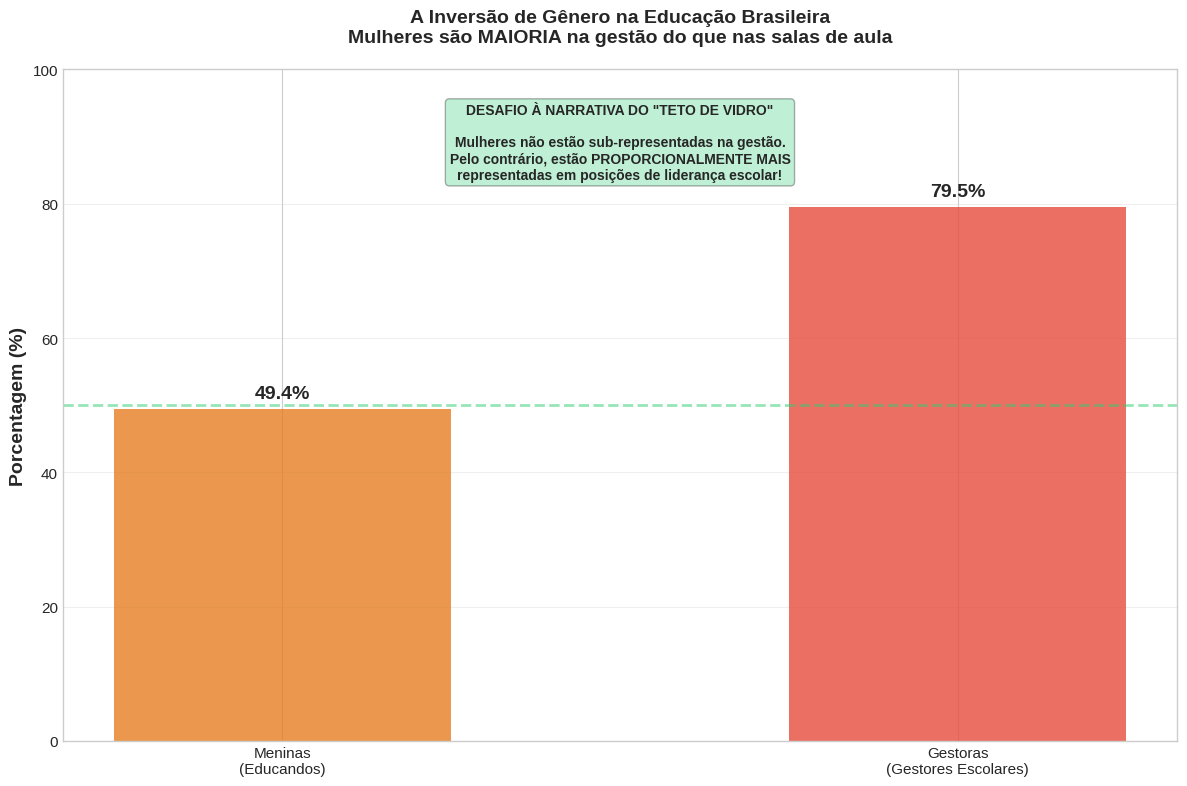


📝 INTERPRETAÇÃO:
Contrariando a narrativa do 'teto de vidro', os dados mostram
que as mulheres DOMINAM as posições de gestão escolar na educação básica.

• 79.5% dos gestores são mulheres
• Apenas 49.4% dos alunos são meninas

Diferença: +30.1 pontos percentuais

Isso sugere que não há barreiras para mulheres alcançarem cargos de gestão.
Pelo contrário, as mulheres estão SUPER-REPRESENTADAS na liderança escolar!


In [13]:
# Criar gráfico comparativo
fig, ax = plt.subplots(figsize=(12, 8))

categorias = ['Meninas\n(Educandos)', 'Gestoras\n(Gestores Escolares)']
valores = [pct_fem, pct_gestoras]
cores_bar = [CORES['feminino'], CORES['destaque']]

bars = ax.bar(categorias, valores, color=cores_bar, alpha=0.8, width=0.5)
ax.axhline(y=50, color=CORES['neutro'], linestyle='--', linewidth=2, alpha=0.5)
ax.set_ylabel('Porcentagem (%)', fontsize=14, fontweight='bold')
ax.set_title('A Inversão de Gênero na Educação Brasileira\nMulheres são MAIORIA na gestão do que nas salas de aula',
             fontsize=14, fontweight='bold', pad=20)
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)

# Adicionar valores e anotações
for bar, val in zip(bars, valores):
    ax.text(bar.get_x() + bar.get_width()/2., val + 1,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=14, fontweight='bold')

plt.annotate('DESAFIO À NARRATIVA DO "TETO DE VIDRO"\n\nMulheres não estão sub-representadas na gestão.\nPelo contrário, estão PROPORCIONALMENTE MAIS\nrepresentadas em posições de liderança escolar!',
             xy=(0.5, 0.95), xycoords='axes fraction',
             fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor=CORES['neutro'], alpha=0.3),
             ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(GRAPHICS_PATH + 'inversao_genero_gestao.png', dpi=300, bbox_inches='tight')
print("💾 Gráfico salvo: inversao_genero_gestao.png")
plt.show()

print("\n📝 INTERPRETAÇÃO:")
print("=" * 60)
print("Contrariando a narrativa do 'teto de vidro', os dados mostram")
print("que as mulheres DOMINAM as posições de gestão escolar na educação básica.")
print("")
print(f"• {pct_gestoras:.1f}% dos gestores são mulheres")
print(f"• Apenas {pct_fem:.1f}% dos alunos são meninas")
print("")
print(f"Diferença: +{pct_gestoras - pct_fem:.1f} pontos percentuais")
print("")
print("Isso sugere que não há barreiras para mulheres alcançarem cargos de gestão.")
print("Pelo contrário, as mulheres estão SUPER-REPRESENTADAS na liderança escolar!")

In [ ]:
# ANÁLISE 1: Correlação entre porte da escola e % de gestoras
print("\n📊 ANÁLISE DE CORRELAÇÃO:")
print("=" * 60)

# Correlação entre porte da escola e % de gestoras
df_corr = df[['QT_MAT_BAS', 'PORC_GESTORAS']].dropna()
correlacao = df_corr['QT_MAT_BAS'].corr(df_corr['PORC_GESTORAS'])

print(f"Correlação entre porte da escola e % de gestoras: {correlacao:.3f}")
print("\nInterpretação:")
if abs(correlacao) < 0.1:
    print("→ Não há correlação significativa")
    print("  O porte da escola NÃO influencia a presença de gestoras")
elif correlacao > 0:
    print(f"→ Correlação POSITIVA moderada ({correlacao:.3f})")
    print("  Escolas maiores tendem a ter MAIS gestoras")
else:
    print(f"→ Correlação NEGATIVA moderada ({correlacao:.3f})")
    print("  Escolas maiores tendem a ter MENOS gestoras")

# ANÁLISE 2: Índice de Representação Feminina
print("\n\n📊 ÍNDICE DE REPRESENTAÇÃO FEMININA:")
print("=" * 60)

# Usar métricas calculadas pela função reutilizável
m = calcular_metricas_principais(df)
indice_representacao = m['pct_gestoras'] / m['pct_fem']

print(f"Proporção de meninas: {m['pct_fem']:.1f}%")
print(f"Proporção de gestoras: {m['pct_gestoras']:.1f}%")
print(f"\nÍndice de Representação: {indice_representacao:.2f}")
print("\nInterpretação:")
if indice_representacao > 1.1:
    print(f"→ Mulheres são SOBRE-REPRESENTADAS na gestão")
    print(f"  (há {indice_representacao:.2f}x mais gestoras do que a proporção de alunas)")
    print("  Isso indica uma INVERSÃO de gênero na gestão escolar")
elif indice_representacao < 0.9:
    print(f"→ Mulheres são SUB-REPRESENTADAS na gestão")
    print(f"  (há {indice_representacao:.2f}x menos gestoras do que a proporção de alunas)")
else:
    print("→ Representação proporcional perfeita")

# ANÁLISE 3: Reflexão Crítica sobre Teto de Vidro
print("\n\n🔍 REFLEXÃO CRÍTICA:")
print("=" * 60)
print("Embora as mulheres sejam maioria na gestão escolar ({:.1f}%),".format(m['pct_gestoras']))
print("é importante analisar com mais nuance:")

# Verificar proporção na rede Federal
df_federal = df[df['TP_DEPENDENCIA'] == 'Federal']
if len(df_federal) > 0:
    gestoras_fed = df_federal['QT_GEST_BAS_FEM'].sum()
    gestores_fed = df_federal['QT_GEST_BAS_MASC'].sum()
    pct_gestoras_fed = (gestoras_fed / (gestoras_fed + gestores_fed)) * 100
    print(f"\n  • Na rede FEDERAL: apenas {pct_gestoras_fed:.1f}% são gestoras")
    print(f"    Isso sugere que o 'teto de vidro' pode existir em")
    print(f"    contextos de maior prestígio e remuneração")

print(f"\n  • A feminização da gestão ({m['pct_gestoras']:.1f}%) pode refletir")
print(f"    a feminização da própria profissão docente")
print(f"    (aprox. 80% são mulheres no magistério)")

print("\n💡 Perguntas para investigação futura:")
print("  • Gestoras têm os mesmos salários que gestores?")
print("  • Escolas maiores/melhores têm mais gestoras ou gestores?")
print("  • Há segmentação por tipo de cargo (diretora vs vice-diretora)?")
print("  • Como isso varia com recorte racial (dados disponíveis)?")

## 5️⃣ Análises Avançadas: Correlação e Representação

## ✅ Resumo do Notebook

### 📊 Análises Concluídas:
- ✅ Panorama nacional de matrículas e gestão
- ✅ Análises por rede de ensino
- ✅ Disparidades regionais
- ✅ Comparação alunas vs gestoras
- ✅ Dashboard integrado

### 📁 Arquivos Gerados:
- `dashboard_completo.png` - Visão geral integrada
- `inversao_genero_gestao.png` - Descoberta chave
- `resumo_executivo.csv` - Métricas principais

### 🔍 Descoberta Chave:

**A INVERSÃO DE GÊNERO NA GESTÃO ESCOLAR**

Os dados revelam que as mulheres são MAIORIA na gestão escolar (79.5%),
enquanto representam apenas 49.4% das matrículas. Isso é o OPOSTO do que
a literatura tradicional sobre "teto de vidro" sugere.

### 🚀 Recomendações para Pesquisa:

1. Investigar por que escolas Federais têm mais gestores homens (26% gestoras)
2. Analisar como esse padrão varia com recorte racial
3. Estudar a relação entre salário, prestigio e gênero na gestão
4. Comparar com dados de outros anos para identificar tendências

---

✨ **Notebook 04 (e projeto) concluído!** ✨

**Desenvolvido com ❤️ por Sara**